### Gradient Descent(GD) using NumPy

In [9]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_regression
from sklearn.model_selection import train_test_split

# Load simple regression dataset
X, y = make_regression(n_samples=200, n_features=1, noise=20, random_state=42)

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Reshape targets to (n_samples, 1)
y_train = y_train.reshape(-1, 1)
y_test = y_test.reshape(-1, 1)

# Gradient Descent function
def gradient_descent(X, y, lr=0.01, epochs=500):
    n_samples, n_features = X.shape
    weights = np.zeros((n_features, 1))
    bias = 0
    losses = []

    for _ in range(epochs):
        y_pred = X @ weights + bias
        error = y_pred - y

        dw = (1 / n_samples) * (X.T @ error)
        db = (1 / n_samples) * np.sum(error)

        weights -= lr * dw
        bias -= lr * db

        loss = (1 / (2 * n_samples)) * np.sum(error ** 2)
        losses.append(loss)

    return weights, bias, losses

# Train
w_gd, b_gd, losses_gd = gradient_descent(X_train, y_train, lr=0.05, epochs=500)

print(f"Final weights (GD NumPy): {w_gd.ravel()}, Bias: {b_gd:.4f}")

Final weights (GD NumPy): [86.51154193], Bias: 2.4461


### Stochastic Gradient Descent (SGD) using PyTorch

In [11]:
import torch
import torch.nn as nn
import torch.optim as optim

# Convert to torch tensors
X_train_torch = torch.from_numpy(X_train).float()
y_train_torch = torch.from_numpy(y_train).float()

# Define simple linear model
model = nn.Linear(1, 1)  # 1 feature input, 1 output

# Loss and optimizer
criterion = nn.MSELoss()
optimizer = optim.SGD(model.parameters(), lr=0.05)

# Training loop
epochs = 500
losses_sgd = []

for _ in range(epochs):
    optimizer.zero_grad()
    outputs = model(X_train_torch)
    loss = criterion(outputs, y_train_torch)
    loss.backward()
    optimizer.step()

    losses_sgd.append(loss.item())

print(f"Final weights (SGD PyTorch): {model.weight.item():.4f}, Bias: {model.bias.item():.4f}")

Final weights (SGD PyTorch): 86.5115, Bias: 2.4461


### Compare GD with SGD by using plot

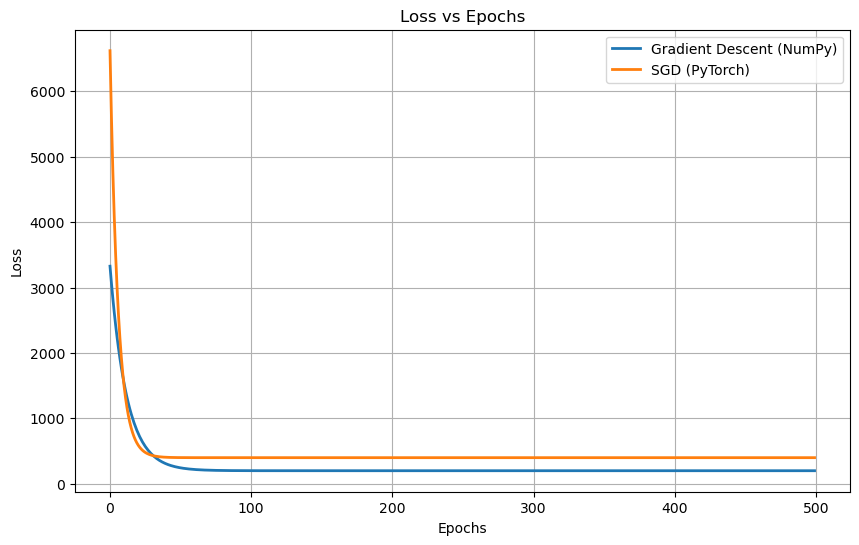

In [12]:
# Plotting Loss Curves
plt.figure(figsize=(10,6))
plt.plot(losses_gd, label='Gradient Descent (NumPy)', linewidth=2)
plt.plot(losses_sgd, label='SGD (PyTorch)', linewidth=2)
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Loss vs Epochs')
plt.legend()
plt.grid(True)
plt.show()

### SGD using Numpy

Epoch 1/50, Loss: 0.5954
Epoch 2/50, Loss: 0.5475
Epoch 3/50, Loss: 0.5347
Epoch 4/50, Loss: 0.5066
Epoch 5/50, Loss: 0.4889
Epoch 6/50, Loss: 0.4765
Epoch 7/50, Loss: 0.4570
Epoch 8/50, Loss: 0.4422
Epoch 9/50, Loss: 0.4296
Epoch 10/50, Loss: 0.4173
Epoch 11/50, Loss: 0.4062
Epoch 12/50, Loss: 0.3954
Epoch 13/50, Loss: 0.3852
Epoch 14/50, Loss: 0.3768
Epoch 15/50, Loss: 0.3706
Epoch 16/50, Loss: 0.3590
Epoch 17/50, Loss: 0.3512
Epoch 18/50, Loss: 0.3444
Epoch 19/50, Loss: 0.3379
Epoch 20/50, Loss: 0.3316
Epoch 21/50, Loss: 0.3260
Epoch 22/50, Loss: 0.3194
Epoch 23/50, Loss: 0.3140
Epoch 24/50, Loss: 0.3092
Epoch 25/50, Loss: 0.3042
Epoch 26/50, Loss: 0.3008
Epoch 27/50, Loss: 0.2954
Epoch 28/50, Loss: 0.2910
Epoch 29/50, Loss: 0.2867
Epoch 30/50, Loss: 0.2847
Epoch 31/50, Loss: 0.2805
Epoch 32/50, Loss: 0.2757
Epoch 33/50, Loss: 0.2726
Epoch 34/50, Loss: 0.2703
Epoch 35/50, Loss: 0.2665
Epoch 36/50, Loss: 0.2634
Epoch 37/50, Loss: 0.2606
Epoch 38/50, Loss: 0.2582
Epoch 39/50, Loss: 0.

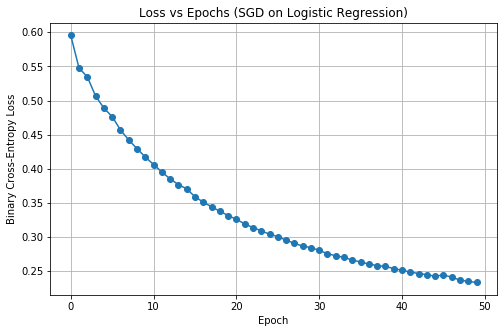

In [2]:
import numpy as np
import matplotlib.pyplot as plt

# ---------- Step 1: Generate a Simple Binary Dataset ----------
# Create 2D data (x1, x2) and binary labels (0 or 1)

def create_dataset(n_samples=100):
    np.random.seed(42)
    # Class 0: Centered at (1,1)
    class_0 = np.random.randn(n_samples // 2, 2) + np.array([1, 1])
    # Class 1: Centered at (3,3)
    class_1 = np.random.randn(n_samples // 2, 2) + np.array([3, 3])

    # Combine data and create labels
    X = np.vstack((class_0, class_1))
    y = np.hstack((np.zeros(n_samples // 2), np.ones(n_samples // 2)))

    return X, y

# ---------- Step 2: Define Sigmoid and Loss Function ----------
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

def binary_cross_entropy(y_true, y_pred):
    # Clip values to avoid log(0)
    eps = 1e-15
    y_pred = np.clip(y_pred, eps, 1 - eps)
    return -np.mean(y_true * np.log(y_pred) + (1 - y_true) * np.log(1 - y_pred))

# ---------- Step 3: Modular SGD Function ----------
def sgd_optimizer(X, y, learning_rate=0.1, epochs=50, batch_size=16, shuffle=True):
    n_samples, n_features = X.shape

    # Initialize weights and bias
    weights = np.zeros(n_features)
    bias = 0

    # For tracking loss
    loss_history = []

    for epoch in range(epochs):
        # Shuffle data if needed
        if shuffle:
            indices = np.arange(n_samples)
            np.random.shuffle(indices)
            X = X[indices]
            y = y[indices]

        # Mini-batch training
        for start in range(0, n_samples, batch_size):
            end = start + batch_size
            X_batch = X[start:end]
            y_batch = y[start:end]

            # Predictions
            linear_output = np.dot(X_batch, weights) + bias
            predictions = sigmoid(linear_output)

            # Gradients
            error = predictions - y_batch
            dw = np.dot(X_batch.T, error) / len(y_batch)
            db = np.mean(error)

            # Update parameters
            weights -= learning_rate * dw
            bias -= learning_rate * db

        # Track and print loss per epoch
        final_preds = sigmoid(np.dot(X, weights) + bias)
        loss = binary_cross_entropy(y, final_preds)
        loss_history.append(loss)
        print(f"Epoch {epoch+1}/{epochs}, Loss: {loss:.4f}")

    return weights, bias, loss_history

# ---------- Step 4: Run Everything ----------
# Generate data
X, y = create_dataset()

# Train using our SGD optimizer
weights, bias, losses = sgd_optimizer(X, y, learning_rate=0.1, epochs=50, batch_size=16)

# ---------- Step 5: Plot Loss vs Epoch ----------
plt.figure(figsize=(8, 5))
plt.plot(losses, marker='o')
plt.title("Loss vs Epochs (SGD on Logistic Regression)")
plt.xlabel("Epoch")
plt.ylabel("Binary Cross-Entropy Loss")
plt.grid(True)
plt.show()

### Rmsprop with Tensorflow

Epoch 1/50
7/7 [==============================] - 1s 3ms/step - loss: 0.7564 - accuracy: 0.4400
Epoch 2/50
7/7 [==============================] - 0s 3ms/step - loss: 0.6651 - accuracy: 0.5700
Epoch 3/50
7/7 [==============================] - 0s 4ms/step - loss: 0.6283 - accuracy: 0.6000
Epoch 4/50
7/7 [==============================] - 0s 3ms/step - loss: 0.6058 - accuracy: 0.6000
Epoch 5/50
7/7 [==============================] - 0s 4ms/step - loss: 0.5883 - accuracy: 0.6000
Epoch 6/50
7/7 [==============================] - 0s 4ms/step - loss: 0.5744 - accuracy: 0.6000
Epoch 7/50
7/7 [==============================] - 0s 4ms/step - loss: 0.5626 - accuracy: 0.6200
Epoch 8/50
7/7 [==============================] - 0s 3ms/step - loss: 0.5515 - accuracy: 0.6300
Epoch 9/50
7/7 [==============================] - 0s 4ms/step - loss: 0.5401 - accuracy: 0.6300
Epoch 10/50
7/7 [==============================] - 0s 4ms/step - loss: 0.5311 - accuracy: 0.6800
Epoch 11/50
7/7 [======================

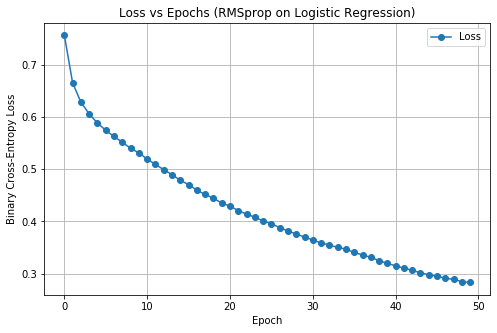

In [1]:
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt

# ---------- Step 1: Generate the Same Dataset ----------
def create_dataset(n_samples=100):
    np.random.seed(42)
    class_0 = np.random.randn(n_samples // 2, 2) + np.array([1, 1])
    class_1 = np.random.randn(n_samples // 2, 2) + np.array([3, 3])
    
    X = np.vstack((class_0, class_1)).astype(np.float32)
    y = np.hstack((np.zeros(n_samples // 2), np.ones(n_samples // 2))).astype(np.float32)
    return X, y

X, y = create_dataset()

# ---------- Step 2: Create a Logistic Regression Model ----------
model = tf.keras.Sequential([
    tf.keras.layers.Dense(1, input_shape=(2,), activation='sigmoid')  # Logistic regression
])

# ---------- Step 3: Compile the Model with RMSprop ----------
model.compile(
    optimizer=tf.keras.optimizers.RMSprop(learning_rate=0.01),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

# ---------- Step 4: Train the Model ----------
history = model.fit(X, y, epochs=50, batch_size=16, verbose=1, shuffle=True)

# ---------- Step 5: Plot Loss vs Epochs ----------
plt.figure(figsize=(8, 5))
plt.plot(history.history['loss'], marker='o', label='Loss')
plt.title("Loss vs Epochs (RMSprop on Logistic Regression)")
plt.xlabel("Epoch")
plt.ylabel("Binary Cross-Entropy Loss")
plt.grid(True)
plt.legend()
plt.show()


### SGD (with momentum) using numpy


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler


In [3]:
# Load dataset
data = pd.read_csv('StudentsPerformance.csv')

# Features and target
features = data.drop(['math score'], axis=1)
target = data['math score']

# One-hot encode categorical features
features = pd.get_dummies(features)

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(features, target, test_size=0.2, random_state=42)

# Standardize features
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Convert to numpy arrays
X_train = np.array(X_train)
X_test = np.array(X_test)
y_train = np.array(y_train)
y_test = np.array(y_test)


In [4]:
def sgd_momentum(X, y, lr=0.01, epochs=200, gamma=0.9):
    n_samples, n_features = X.shape
    weights = np.zeros(n_features)
    velocity = np.zeros(n_features)
    losses = []

    for epoch in range(epochs):
        y_pred = X @ weights
        loss = np.mean((y_pred - y) ** 2)
        losses.append(loss)
        
        grad = 2 * X.T @ (y_pred - y) / n_samples
        
        velocity = gamma * velocity + lr * grad
        weights -= velocity
        
    return weights, losses

# Train with SGD Momentum
weights_momentum, losses_momentum = sgd_momentum(X_train, y_train)


### Adam optimizer using pytorch

In [5]:
# Convert data to torch tensors
X_train_torch = torch.tensor(X_train, dtype=torch.float32)
y_train_torch = torch.tensor(y_train, dtype=torch.float32).unsqueeze(1)

# Define simple linear model
model = nn.Linear(X_train.shape[1], 1)
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.01)

# Train model
adam_losses = []
epochs = 200

for epoch in range(epochs):
    model.train()
    
    optimizer.zero_grad()
    outputs = model(X_train_torch)
    loss = criterion(outputs, y_train_torch)
    loss.backward()
    optimizer.step()
    
    adam_losses.append(loss.item())


### Plotting loss curves

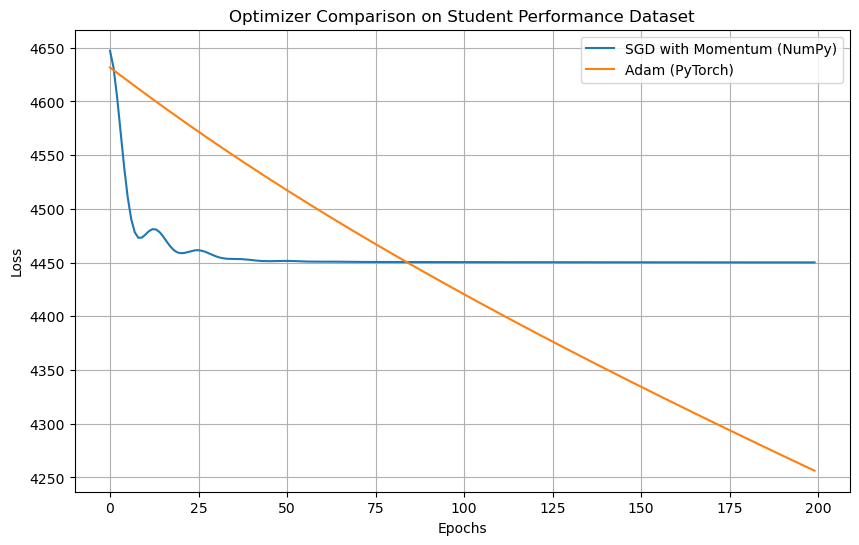

In [6]:
plt.figure(figsize=(10,6))
plt.plot(losses_momentum, label="SGD with Momentum (NumPy)")
plt.plot(adam_losses, label="Adam (PyTorch)")
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Optimizer Comparison on Student Performance Dataset')
plt.legend()
plt.grid(True)
plt.show()
